In [ ]:
import numpy as np  # Work with numbers and random draws
import pandas as pd  # Handle table-style data
import matplotlib.pyplot as plt  # Plot charts
import seaborn as sns  # Make nicer plots
from sklearn.model_selection import train_test_split  # Split data into train and test sets
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Decision tree model and plotting helper
from sklearn.metrics import accuracy_score  # Measure how often model is correct

import warnings  # Control warnings
warnings.filterwarnings('ignore')  # Hide non-critical warnings

np.random.seed(42)  # Make random numbers repeat each run
n = 200  # Number of pretend customers

# 1. Features
 # Age: Between 10 and 60
age = np.random.randint(10, 60, n)  # Random ages between 10 and 60
 # Income: Between 0 and 10,000 TL
income = np.random.randint(0, 10000, n)  # Random incomes
 # 2. Target (Is Premium Member?)
 # Rules:
 # - RULE 1: If under 18 -> Usually No (0)
 # - RULE 2: If over 18 AND Income is more than 5000 -> Yes (1)
 # - RULE 3: If over 18 AND Income is less than 5000 -> No (0)

premium = []  # Empty list to store yes/no answers
for y, g in zip(age, income):  # Walk through each person's age and income
    if y < 18:
        # Children usually do not buy (%10 exception/noise added)
        premium.append(1 if np.random.random() < 0.1 else 0)  # Small chance of yes
    else:
        if g > 5000:
            # Wealthy adults usually buy (%90 probability)
            premium.append(1 if np.random.random() < 0.9 else 0)  # High chance of yes
        else:
            # Low-income adults usually do not buy
            premium.append(0)  # No

df_tree = pd.DataFrame({'Age': age, 'Income': income, 'Premium': premium})  # Build table

print(df_tree.head(10))  # Show first 10 rows

   Age  Income  Premium
0   48    1998        0
1   38    7994        1
2   24    1495        0
3   52    3304        0
4   17    3763        0
5   30    5232        1
6   48    1853        0
7   28    6585        1
8   32    1291        0
9   20    3581        0


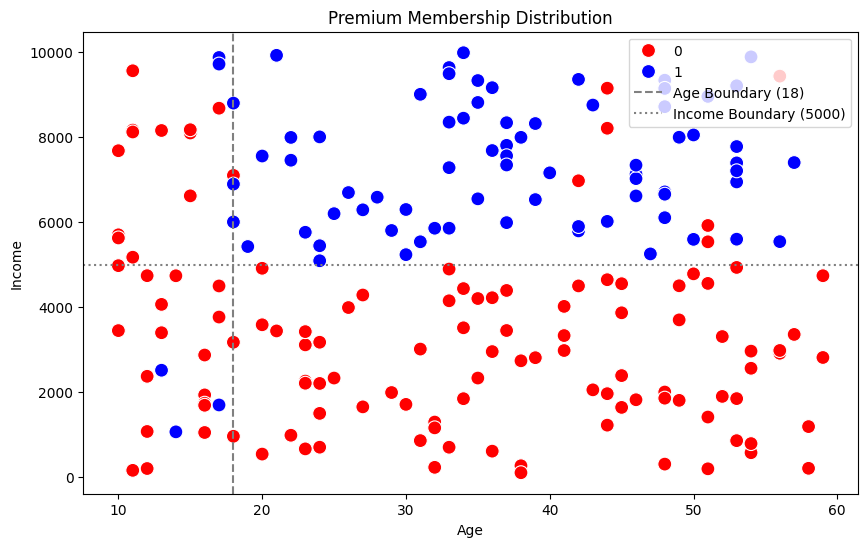

In [2]:
plt.figure(figsize=(10, 6))  # Make a wide plot
sns.scatterplot(x='Age', y='Income', hue='Premium', data=df_tree, palette=['red', 'blue'], s=100)  # Plot people colored by premium
 # Let's draw the critical boundaries as imaginary lines
plt.axvline(x=18, color='gray', linestyle='--', label='Age Boundary (18)')  # Vertical line at age 18
plt.axhline(y=5000, color='gray', linestyle=':', label='Income Boundary (5000)')  # Horizontal line at income 5000

plt.title('Premium Membership Distribution')  # Add title
plt.legend()  # Show legend
plt.show()  # Display plot

In [ ]:
X = df_tree[['Age', 'Income']]  # Inputs: age and income
y = df_tree['Premium']  # Output: premium yes/no

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data

# Create the model (Allow maximum depth of 3)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)  # Initialize the tree model with max depth 3 
tree_model.fit(X_train, y_train)  # Train the tree

print("Decision Tree Model Trained.")  # Confirm training

Decision Tree Model Trained.


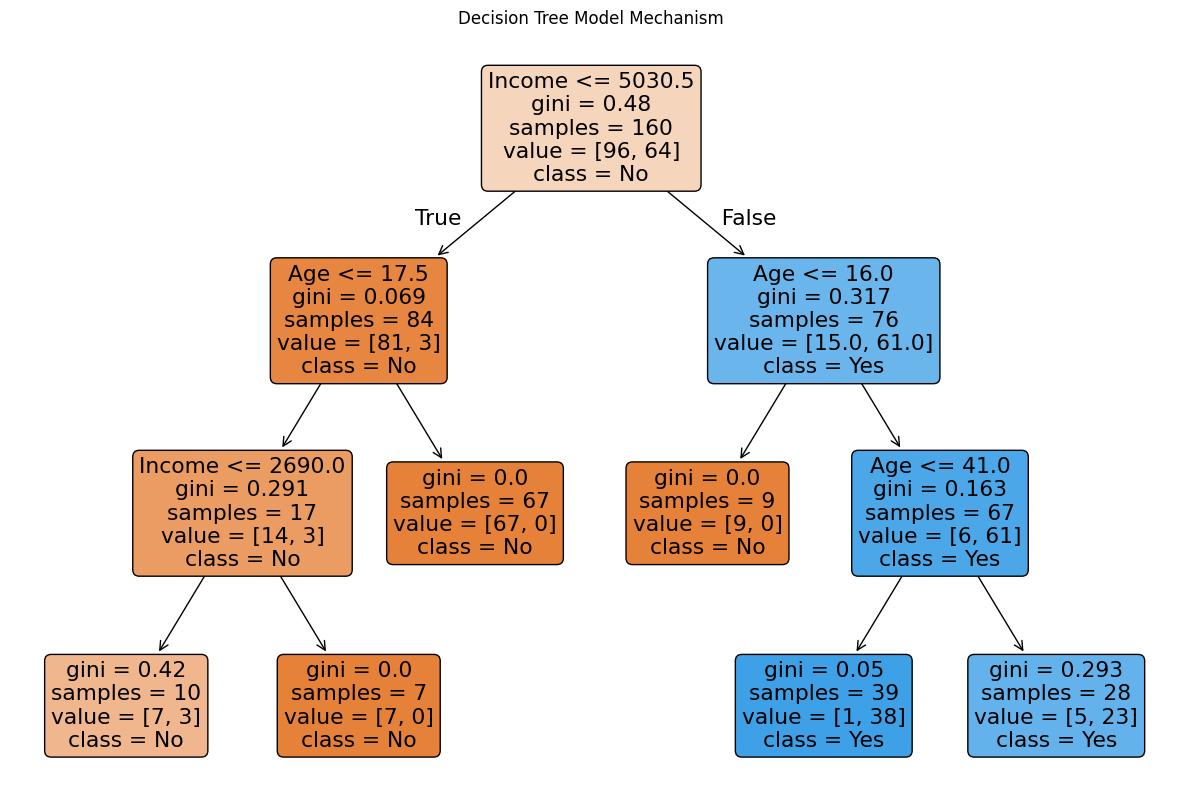

In [4]:
plt.figure(figsize=(15, 10))  # Large figure to see the whole tree
plot_tree(tree_model,  # Draw the decision tree
          feature_names=['Age', 'Income'],  # Label the input columns
          class_names=['No', 'Yes'],  # Label the output classes
          filled=True,  # Color nodes by class
          rounded=True)  # Round corners for readability
plt.title("Decision Tree Model Mechanism")  # Title
plt.show()  # Display the tree diagram

<Figure size 1000x600 with 0 Axes>

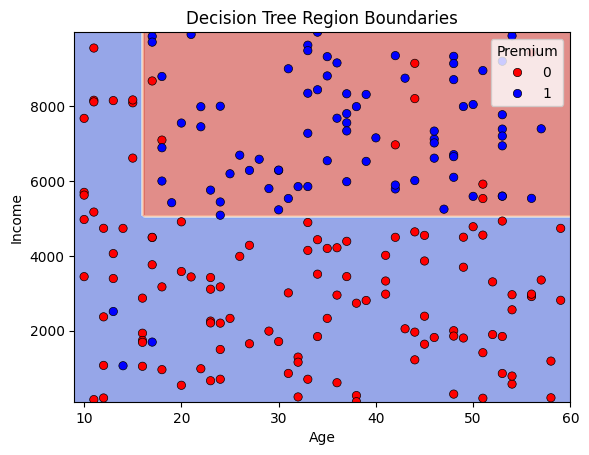

In [5]:
from sklearn.inspection import DecisionBoundaryDisplay  # Helper to draw decision regions

plt.figure(figsize=(10, 6))  # Make a wide plot
DecisionBoundaryDisplay.from_estimator(
    tree_model,  # Use our trained tree
    X,  # Data to set the grid size
    cmap='coolwarm',  # Colors for classes
    response_method='predict',  # Use predicted class for coloring
    alpha=0.6
)

# Let's plot the actual points on top
sns.scatterplot(x='Age', y='Income', hue='Premium', data=df_tree, palette=['red', 'blue'], edgecolor='black')  # Actual people
plt.title('Decision Tree Region Boundaries')  # Title
plt.show()  # Display plot

In [6]:
# Predictions and Accuracy
y_pred = tree_model.predict(X_test)  # Ask tree to guess for test data
acc = accuracy_score(y_test, y_pred)  # Measure fraction correct
print(f"Model Accuracy: %{acc * 100:.2f}")  # Show accuracy

# Example Customer Scenarios
 # 1. Customer: 16 years old, Father is wealthy (Income 8000) -> Should be limited by age rule
 # 2. Customer: 35 years old, Income 7000 -> Should buy
examples = [[16, 8000], [35, 7000]]  # Two sample people
predictions = tree_model.predict(examples)  # Predict for them

print(f"Does the 16-year-old customer buy? {'Yes' if predictions[0]==1 else 'No'}")  # Show result for teen
print(f"Does the 35-year-old customer buy? {'Yes' if predictions[1]==1 else 'No'}")  # Show result for adult

Model Accuracy: %95.00
Does the 16-year-old customer buy? No
Does the 35-year-old customer buy? Yes
